# Extract Specialist Data

Extracts specialist (Item / ItemWithBoost) assets from Anno 117 into CSV and JSON files. Output goes to `results/tables/`.

Run all cells from the project root.

## Load Assets

Setup game data for processing.

In [1]:
from assetextractor.extraction.utils import Config
from assetextractor.parsing.core.assets import AssetCache

config = Config.from_json("config.json")
assets = AssetCache.load(config)
templates = assets.templates

print(f"Total assets: {len(assets.elements)}")
print(f"Total texts: {len(assets.texts.elements)}")

Total assets: 32911
Total texts: 34736


## Quick Color Test

In [2]:
from typing import cast
from assetextractor.parsing.core.attributes import ColorAttribute, DictAttribute

rarities = [
    "Common",
    "Uncommon",
    "Rare",
    "Epic",
    "Legendary",
    "Quest",
    "Unique"
]

asset_color_config = assets.get(140577)
color_item_rarity_dict = cast("dict | None", asset_color_config.find("ColorConfig.ItemRarityColors"))

print(f"{'Rarity':<12} | {'Hex (Web)':<12} | {'RGBA Tuple'}")
print("-" * 50)

for rarity in rarities:
    rarity_dict: DictAttribute = color_item_rarity_dict.get(rarity)
    
    if rarity_dict:
        color_attr: ColorAttribute = rarity_dict.value.get("Color")
        if color_attr:
            hex_val = color_attr.get_hex()
            rgba_val = color_attr.get_rgba()
            print(f"{rarity:<12} | {hex_val:<12} | {rgba_val}")

Rarity       | Hex (Web)    | RGBA Tuple
--------------------------------------------------
Common       | #ffffffff    | (255, 255, 255, 255)
Uncommon     | #659e2dff    | (101, 158, 45, 255)
Rare         | #3e5496ff    | (62, 84, 150, 255)
Epic         | #a563a7ff    | (165, 99, 167, 255)
Legendary    | #c76937ff    | (199, 105, 55, 255)
Quest        | #4a3860ff    | (74, 56, 96, 255)
Unique       | #d4d406ff    | (212, 212, 6, 255)


## Extract Specialist Assets.

Extract the specialists from `Item` and `ItemWithBoost` and print the quantity of assets.

In [3]:
# Misc: This allow reloading .py modules into jupyter.
%load_ext autoreload
%autoreload 3

In [4]:
from assetextractor.conversion.statistics.specialist_extractor import SpecialistExtractor

extractor = SpecialistExtractor(assets)
# extractor_de = SpecialistExtractor(assets, language="german")
specialist_collection_data = extractor.extract_all()

specialists_data = specialist_collection_data.items
specialists_boost_data = specialist_collection_data.items_with_boost

print(f"Processed {len(specialists_data.keys())} specialists.")
print(f"Processed {len(specialists_boost_data.keys())} specialists with boost.")

Processed 374 specialists.
Processed 120 specialists with boost.


## Print Specialists and their details

Use `extractor.print_specialists()` to see everything, or `extractor.print_specialists(guid=71438)` (*"Gaius Julius Lupus, Castor of Fortunes"* as example) to inspect a specific one.


               SPECIALIST (WITH BOOST): Dorian, Philos of Philhellenes (GUID: 41350)                



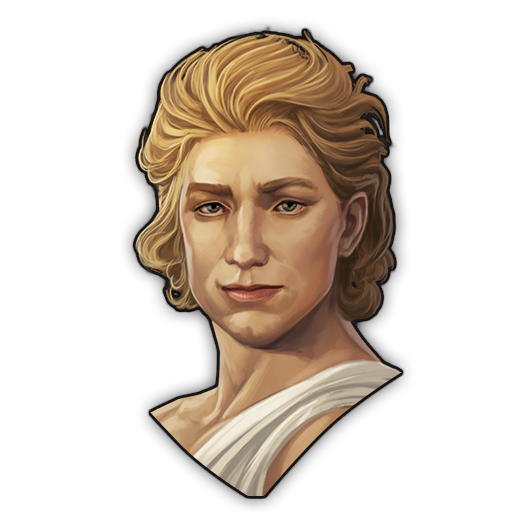

----------------------------------------------------------------------------------------------------
Allocation:    Villa
Rarity:        Unique
Niche:         Culture
Trade Price:   1000
Origin:        BaseRelease
----------------------------------------------------------------------------------------------------
     Boost Condition: Health >= 1000
     Boost Hint:      Promotes health and brotherhood
     └── Buff #1: Specialist Rival 01 Dorian Buff Boosted (GUID: 113061)
         ├── [Additional Workforce]: Libertus Workforce (GUID: 2181)
         ├── [Building Upgrade Attributes]:
         │   └── [Health]:       +35%       (Raw: 35.0)
         ├── [Residence Upgrade Attributes]:
         │   ├── [Health]:       +3         (Raw: 3.0)
         │   └── [Fire Safety]:  +2         (Raw: 2.0)
         │       └── [Changed Need Attributes]:
         │           └── Service Roman Baths (GUID: 2685) - Baths
-----------------------------------------------------------------------------------

In [5]:
# extractor.print_specialists(44149) # Maxima Cottius, Upholsterer of Atlas

# extractor.print_specialists(144866) # Olive Reaper (From PoA DLC)

# extractor.print_specialists(44431) # Elephant Handler

extractor.print_specialists(41350) # Specialist Rival 01 Dorian.
# This one has percentage attributes.

# extractor.print_specialists(51361) # Stranded Sandal

# extractor.print_specialists(71542) # Captain Nautics R Transfer
# Has ShipBuff (GUID: 71541): Swift Offloader

# extractor.print_specialists(91415) # Judoc Daidalos, of the Myrtle Tower
# Has DefenseBuildingBuff (GUID: 91416): Judoc Daidalos, of the Myrtle Tower

# extractor.print_specialists(106654) # Cranncriomhthann, Oaken Nonagenarian
# Has BuildingBuff with a MaintenanceUpgrade that replaces workforce. 
# (GUID: 106655): Cranncriomhthann, Oaken Nonagenarian

# extractor.print_specialists(92880) # Herius Fraucus Cornelius, Patrician Palatine
# Has workforce modifier in percent value of 25.0

# extractor.print_specialists(149292) # Ancharia, Darling of the Lares Compitales
# Has nested asset pool list within the targets

# extractor.print_specialists(80513) # Incidentus, Consular Horse
# ItemWithBoost + AdditionalFunctionalEffect within the main buff.

# extractor.print_specialists(42043) # Magnus Bantius the Deipnosophist
# Item + AdditionalFunctionalEffect within the main buff.

## Export to JSON & Image Export

Using the `save_to_json` method from the extractor. You can pass a custom `web_base_path` to fit your webapp asset structure. If left empty, it will provide the original image game path within the asset extractor.

The `IconProcessor` is a static utility class designed for batch processing, resizing, and converting `.dds` game icons into web-ready `.webp` files.

The `IconProcessor.export_icons()` method allows for either a Flattened structure (optimized for simple galleries) or a Mirrored structure (mimicking the game's internal directory hierarchy).

This is done by using wand + magick within the IconProcessor.

In [6]:
from pathlib import Path

# Define base output folder
output_root = Path("results")

In [7]:
# Export the simplified JSON
# You can pass any file path (e.g., Path("data/specialists_simplified.json"))
output_file = output_root / "tables/specialists_en_simplified.json"
extractor.export_simplified_json(
    output_file,
    web_base_path="assets/icons", 
    flatten=False
)

Simplified export completed to results\tables\specialists_en_simplified.json


In [8]:
# Export Assets Index
extractor.export_assets_index_json(
    output_root / "tables/specialist_asset_ref.json",
    web_base_path="assets/icons", 
    flatten=False
)

Asset index exported to results\tables\specialist_asset_ref.json


In [9]:
# =================================================================
# SCENARIO A: MIRRORED STRUCTURE (Mimics Game Folders)
# Use this for: Webapps that need the full "base/icon_content/..." tree.
# =================================================================
print(f" Scenario A: Mirrored ".center(80, "*"))
    
# 1. Export ALL physical files (Icons @ 128px)
# Recreates the game's directory hierarchy for everything.

extractor.export_all_assets(
    output_base=output_root / "icons",
    quality=75,
    flatten=False,           # Mirror hierarchy for standard assets & portraits
    export_ref_assets=True   # Export all reference assets as well.
)

# 2. Save JSON with URLs like: "base/icon_content/religion/icon_name.webp"
# extractor.save_to_json(
#     file_path=output_root / "tables/specialists_en.json",
#     web_base_path="assets/icons",  # No prefix (None) -> relative path from game tree root
#     flatten=False             # Matches the mirrored file export paths
# )

***************************** Scenario A: Mirrored *****************************
Exporting 494 specialist icons...
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_75_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_female\icon_3d_celtic_female_026_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_male\icon_3d_celtic_male_014_0.webp
  [OK] -> icons\base\icon_content\items_specialist\celtic_male\icon_3d_celtic_male_005_0.webp
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_006_0.webp
  [OK] -> icons\base\icon_content\items_specialist\nonbinary\icon_3d_celtic_nb_02_0.webp
  [OK] -> icons\base\icon_content\items_specialist\roman_male\icon_3d_roman_male_019_0.webp
  [OK] -> icons\base\icon_content\items_specialist\unique\icon_3d_unique_005_circaeus_of_aeaea_0.webp
  [OK] -> icons\base\icon_content\items_specialist\unique\icon_3d_specialist_hooded_01_0.webp
  [OK] -> icons\base\icon_content\items